# CRISP-DM Pipeline for Stock Price Prediction

This notebook is structured following the Cross-Industry Standard Process for Data Mining (CRISP-DM) methodology to predict stock prices for Indonesian banks.

## 1. Business Understanding

The primary objective is to build a Recurrent Neural Network (RNN) model to predict stock prices for Indonesian banks. This involves understanding the stock market data, developing a predictive model, and evaluating its performance. The insights gained can be used for investment strategies or risk assessment.

**Process Overview:**
1.  **Data Acquisition**: Downloading historical stock data from Yahoo Finance.
2.  **Data Preprocessing**: Preparing the data for the RNN model.
3.  **Model Building**: Defining and training a SimpleRNN architecture.
4.  **Evaluation**: Assessing model performance with metrics and visualization.
5.  **Deployment Considerations**: Discussing how the model might be deployed.

In [ ]:
# Install necessary libraries
!pip install yfinance tensorflow scikit-learn matplotlib

## 2. Data Understanding

In this phase, we acquire the historical stock price data and perform initial explorations to understand its structure, content, and quality. We'll download 'Close' prices for selected Indonesian bank tickers.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN
import matplotlib.pyplot as plt


indonesian_bank_tickers = [
    'BBCA.JK', # Bank Central Asia Tbk
    'BBRI.JK', # Bank Rakyat Indonesia (Persero) Tbk
    'BBNI.JK', # Bank Negara Indonesia (Persero) Tbk
    'BMRI.JK', # Bank Mandiri (Persero) Tbk
    'BTPS.JK'  # Bank Tabungan Pensiunan Nasional Syariah Tbk
]


start_date = '2025-09-01'
end_date = '2026-03-31'


all_data = yf.download(indonesian_bank_tickers, start=start_date, end=end_date)

# Extract 'Close' prices for all stocks
close_prices = all_data['Close']

# Display the first few rows of the close prices
print("Close Prices Data:")
display(close_prices.head())

/tmp/ipykernel_2490/2019213705.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  all_data = yf.download(indonesian_bank_tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed


Close Prices Data:


Ticker,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,BTPS.JK
Date,,,,,
2025-09-01,7614.143555,3976.158203,3602.707275,4141.812500,1356.248413
2025-09-02,7614.143555,3966.954102,3584.603027,4114.800781,1365.537842
2025-09-03,7590.349609,4058.994873,3647.967285,4159.820801,1346.959106
2025-09-04,7614.143555,4022.178467,3620.811279,4213.844238,1356.248413
2025-09-08,7328.613281,3847.301270,3530.291016,4042.769287,1254.065430


## 3. Data Preparation

This stage involves cleaning, transforming, and constructing the final dataset for modeling. Key steps include handling missing values, normalizing data, and creating sequences suitable for the RNN model.

In [3]:
# Fill any missing values using forward fill, then backward fill
close_prices = close_prices.fillna(method='ffill').fillna(method='bfill')

# Check for any remaining missing values
print("Missing values after imputation:")
print(close_prices.isnull().sum())

# Normalize each stock's data independently
scalers = {}
scaled_data = pd.DataFrame(index=close_prices.index)

for ticker in indonesian_bank_tickers:
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_column = scaler.fit_transform(close_prices[[ticker]])
    scaled_data[ticker] = scaled_column.flatten()
    scalers[ticker] = scaler

print("\nScaled Data Head:")
display(scaled_data.head())

# Function to create sequences for RNN
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length), :])
        y.append(data[i + sequence_length, :])
    return np.array(X), np.array(y)

sequence_length = 60

# Prepare data for all stocks
X_all, y_all = create_sequences(scaled_data.values, sequence_length)

print(f"Shape of X_all (sequences): {X_all.shape}")
print(f"Shape of y_all (targets): {y_all.shape}")


split_ratio = 0.8
split_index = int(len(X_all) * split_ratio)

X_train, X_test = X_all[:split_index], X_all[split_index:]
y_train, y_test = y_all[:split_index], y_all[split_index:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

/tmp/ipykernel_2490/2874800313.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close_prices = close_prices.fillna(method='ffill').fillna(method='bfill')


Missing values after imputation:
Ticker
BBCA.JK    0
BBNI.JK    0
BBRI.JK    0
BMRI.JK    0
BTPS.JK    0
dtype: int64

Scaled Data Head:


,BBCA.JK,BBRI.JK,BBNI.JK,BMRI.JK,BTPS.JK
Date,,,,,
2025-09-01,0.642074,0.646431,0.639535,0.383653,0.858436
2025-09-02,0.642074,0.620241,0.627907,0.362727,0.880215
2025-09-03,0.629291,0.711907,0.744186,0.397605,0.836657
2025-09-04,0.642074,0.672622,0.697674,0.439458,0.858436
2025-09-08,0.488677,0.541670,0.476744,0.306923,0.618867


Shape of X_all (sequences): (78, 60, 5)
Shape of y_all (targets): (78, 5)
X_train shape: (62, 60, 5), y_train shape: (62, 5)
X_test shape: (16, 60, 5), y_test shape: (16, 5)


## 4. Modeling

This stage focuses on selecting and applying modeling techniques. We will define a SimpleRNN architecture, compile and train it, and also explore hyperparameter tuning to optimize its performance.

Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 50)         │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,105 (31.66 KB)

 Trainable params: 8,105 (31.66 KB)

 Non-trainable params: 0 (0.00 B)


Training the model...
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step - loss: 0.6348 - val_loss: 0.2634
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.3463 - val_loss: 0.0994
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.2863 - val_loss: 0.0898
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.2208 - val_loss: 0.0914
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.2531 - val_loss: 0.0836
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.2397 - val_loss: 0.0703
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.2104 - val_loss: 0.0500
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.2098 - val_loss: 0.0423
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.2159 - val_loss: 0.0537
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.2347 - val_loss: 0.0414
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.2049 - val_loss: 0.0390
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.

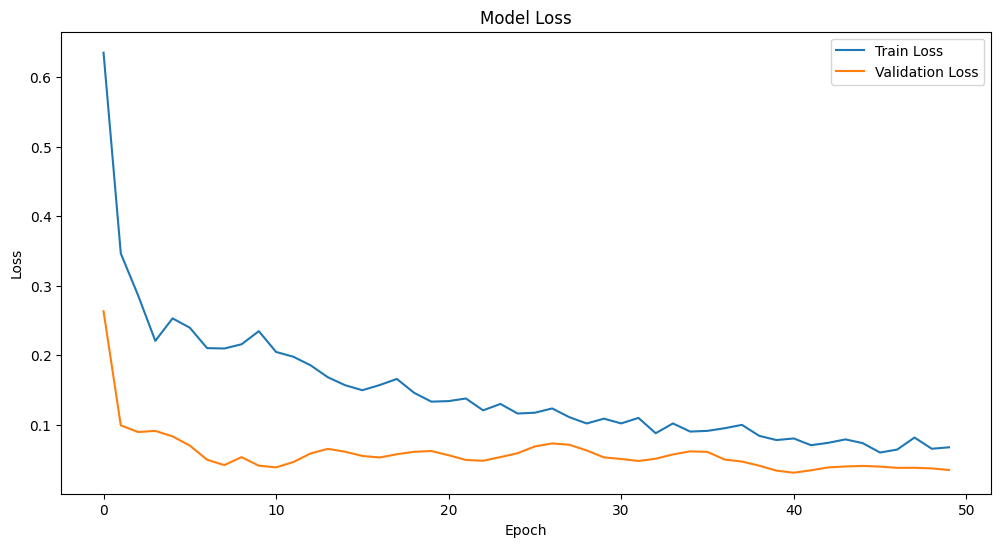

In [19]:
# Define the RNN (SimpleRNN) model
model = Sequential()
model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=y_train.shape[1])) # Output layer with units equal to the number of stocks

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
print("Model Summary:")
model.summary()

# Train the model
print("\nTraining the model...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("Model training complete.")

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

### Hyperparameter Tuning: Sequence Length

We will now compare the model's performance using different sequence lengths to understand its impact on prediction accuracy. We will test `sequence_length` values of 30, 60, and 90 days.

In [11]:
import gc
from tensorflow.keras import backend as K
from sklearn.metrics import mean_absolute_error, mean_squared_error

def run_model_with_sequence_length(seq_len, scaled_data, indonesian_bank_tickers, scalers, epochs=25, batch_size=32):
    print(f"\n--- Running model with sequence_length: {seq_len} ---")

    # Create sequences for RNN with the given sequence_length
    X_all_curr, y_all_curr = create_sequences(scaled_data.values, seq_len)


    split_ratio = 0.8
    split_index = int(len(X_all_curr) * split_ratio)

    X_train_curr, X_test_curr = X_all_curr[:split_index], X_all_curr[split_index:]
    y_train_curr, y_test_curr = y_all_curr[:split_index], y_all_curr[split_index:]

    print(f"X_train shape: {X_train_curr.shape}, y_train shape: {y_train_curr.shape}")
    print(f"X_test shape: {X_test_curr.shape}, y_test shape: {y_test_curr.shape}")

    # Define the SimpleRNN model (reusing previous architecture)
    model = Sequential()
    model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train_curr.shape[1], X_train_curr.shape[2])))
    model.add(Dropout(0.2))
    model.add(SimpleRNN(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=y_train_curr.shape[1])) # Output layer with units equal to the number of stocks

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train_curr, y_train_curr, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0) # Set verbose to 0 for cleaner output during tuning

    # Make predictions on the test data
    predictions = model.predict(X_test_curr)

    # Inverse transform the predictions and actual values for each stock
    actual_prices = {}
    predicted_prices = {}
    metrics_results = {ticker: {} for ticker in indonesian_bank_tickers}

    for i, ticker in enumerate(indonesian_bank_tickers):
        stock_predictions_scaled = predictions[:, i].reshape(-1, 1)
        stock_actuals_scaled = y_test_curr[:, i].reshape(-1, 1)

        actual_prices[ticker] = scalers[ticker].inverse_transform(stock_actuals_scaled)
        predicted_prices[ticker] = scalers[ticker].inverse_transform(stock_predictions_scaled)

        # Calculate metrics
        mae = mean_absolute_error(actual_prices[ticker], predicted_prices[ticker])
        mse = mean_squared_error(actual_prices[ticker], predicted_prices[ticker])
        rmse = np.sqrt(mse)

        metrics_results[ticker] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}

    # Clear TensorFlow session and collect garbage to free memory
    K.clear_session()
    del model
    del X_all_curr, y_all_curr, X_train_curr, y_train_curr, X_test_curr, y_test_curr, predictions
    gc.collect()

    return metrics_results, history.history['val_loss'][-1]

In [17]:
# Define sequence lengths to test
sequence_lengths_to_test = [30, 60, 90]

all_tuning_results = {}

for seq_len in sequence_lengths_to_test:
    metrics_per_stock, final_val_loss = run_model_with_sequence_length(
        seq_len=seq_len,
        scaled_data=scaled_data,
        indonesian_bank_tickers=indonesian_bank_tickers,
        scalers=scalers,
        epochs=50, # Keeping epochs consistent for comparison
        batch_size=32 # Keeping batch_size consistent for comparison
    )
    all_tuning_results[seq_len] = {'metrics': metrics_per_stock, 'final_val_loss': final_val_loss}

print("\n--- Summary of Hyperparameter Tuning Results (Sequence Length) ---")
for seq_len, results in all_tuning_results.items():
    print(f"\nSequence Length: {seq_len} days")
    print(f"  Final Validation Loss: {results['final_val_loss']:.4f}")
    for ticker, metrics in results['metrics'].items():
        print(f"    Stock: {ticker} - MAE: {metrics['MAE']:.2f}, RMSE: {metrics['RMSE']:.2f}")


--- Running model with sequence_length: 30 ---
X_train shape: (86, 30, 5), y_train shape: (86, 5)
X_test shape: (22, 30, 5), y_test shape: (22, 5)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step

--- Running model with sequence_length: 60 ---
X_train shape: (62, 60, 5), y_train shape: (62, 5)
X_test shape: (16, 60, 5), y_test shape: (16, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step

--- Running model with sequence_length: 90 ---
X_train shape: (38, 90, 5), y_train shape: (38, 5)
X_test shape: (10, 90, 5), y_test shape: (10, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step

--- Summary of Hyperparameter Tuning Results (Sequence Length) ---

Sequence Length: 30 days
  Final Validation Loss: 0.0242
    Stock: BBCA.JK - MAE: 409.10, RMSE: 474.52
    Stock: BBRI.JK - MAE: 92.41, RMSE: 111.79
    Stock: BBNI.JK - MAE: 63.57, RMSE: 87.07
    Stock: BMRI.JK - MAE: 288.64, RMSE: 344.95
    Stock: BTPS.JK - MAE: 44.29, RMSE: 53.27

Sequence Length: 60 days
  Final Validation Loss: 0.0260
    Stock: BBCA.JK - MAE: 355.02, RMSE: 404.80
    Stock: BBRI.JK - MAE: 199.12, RMSE: 215.19
    Stock: BBNI.JK - MAE: 132.50, RMSE: 154.13
    Stock: BMRI.JK - MAE: 119.59, RMSE: 146.84
    Stock: BTPS.JK - MAE: 72.26, RMSE: 83.91

Sequence Length: 90 days
  Final Validation Loss: 0.0664
    Stock: BBCA.JK - MAE: 370.82, RMSE: 412.52
    Stock: BBRI.JK - MAE: 80.13, RMSE: 99.62
    Stock: BBNI.JK - MAE: 252.70, RMSE: 286.05
    Stock: BMRI.JK - MAE: 793.92, RMSE: 805.49
    Stock: BTPS.JK - MAE: 106.64, RMSE: 122.74


## 5. Evaluation

In this phase, we evaluate the model's performance rigorously and assess its effectiveness in meeting the business objectives. This includes making predictions, visualizing results, calculating quantitative metrics, and analyzing the impact of hyperparameter choices.

In [20]:
# Make predictions on the test data
predictions = model.predict(X_test)

# Inverse transform the predictions and actual values for each stock
actual_prices = {}
predicted_prices = {}

for i, ticker in enumerate(indonesian_bank_tickers):
    # Extract predictions and actuals for the current stock
    stock_predictions_scaled = predictions[:, i].reshape(-1, 1)
    stock_actuals_scaled = y_test[:, i].reshape(-1, 1)

    # Inverse transform using the corresponding scaler
    actual_prices[ticker] = scalers[ticker].inverse_transform(stock_actuals_scaled)
    predicted_prices[ticker] = scalers[ticker].inverse_transform(stock_predictions_scaled)

# Display some of the inverse transformed results
print("\nInverse Transformed Predicted vs Actual Prices (first 5 samples for each stock):")
for ticker in indonesian_bank_tickers:
    print(f"\nStock: {ticker}")
    df_compare = pd.DataFrame({
        'Actual': actual_prices[ticker].flatten(),
        'Predicted': predicted_prices[ticker].flatten()
    })
    display(df_compare.head())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step

Inverse Transformed Predicted vs Actual Prices (first 5 samples for each stock):

Stock: BBCA.JK


,Actual,Predicted
0,6730.369629,6980.991211
1,6778.272461,7183.708008
2,6586.660645,7151.933594
3,6802.224121,7257.200684
4,6706.417969,7181.927734



Stock: BBRI.JK


,Actual,Predicted
0,3587.912842,3620.091553
1,3540.950684,3628.079590
2,3465.811035,3547.845215
3,3522.165771,3547.582031
4,3447.026367,3560.530273



Stock: BBNI.JK


,Actual,Predicted
0,3957.750000,4271.145020
1,3957.750000,4302.862305
2,3819.688965,4193.896484
3,3939.342041,4264.160645
4,3930.137939,4291.181641



Stock: BMRI.JK


,Actual,Predicted
0,4661.812988,4924.618164
1,4684.777344,4893.094238
2,4574.547363,4483.584961
3,4707.742188,4642.689453
4,4574.547363,4689.983887



Stock: BTPS.JK


,Actual,Predicted
0,1052.281738,1085.739014
1,1057.064819,1072.736084
2,1009.233826,1177.067627
3,1037.932373,1233.733276
4,1023.583130,1220.457642


### Visualize Predictions

Let's visualize the actual versus predicted stock prices for each bank to assess the model's performance visually.

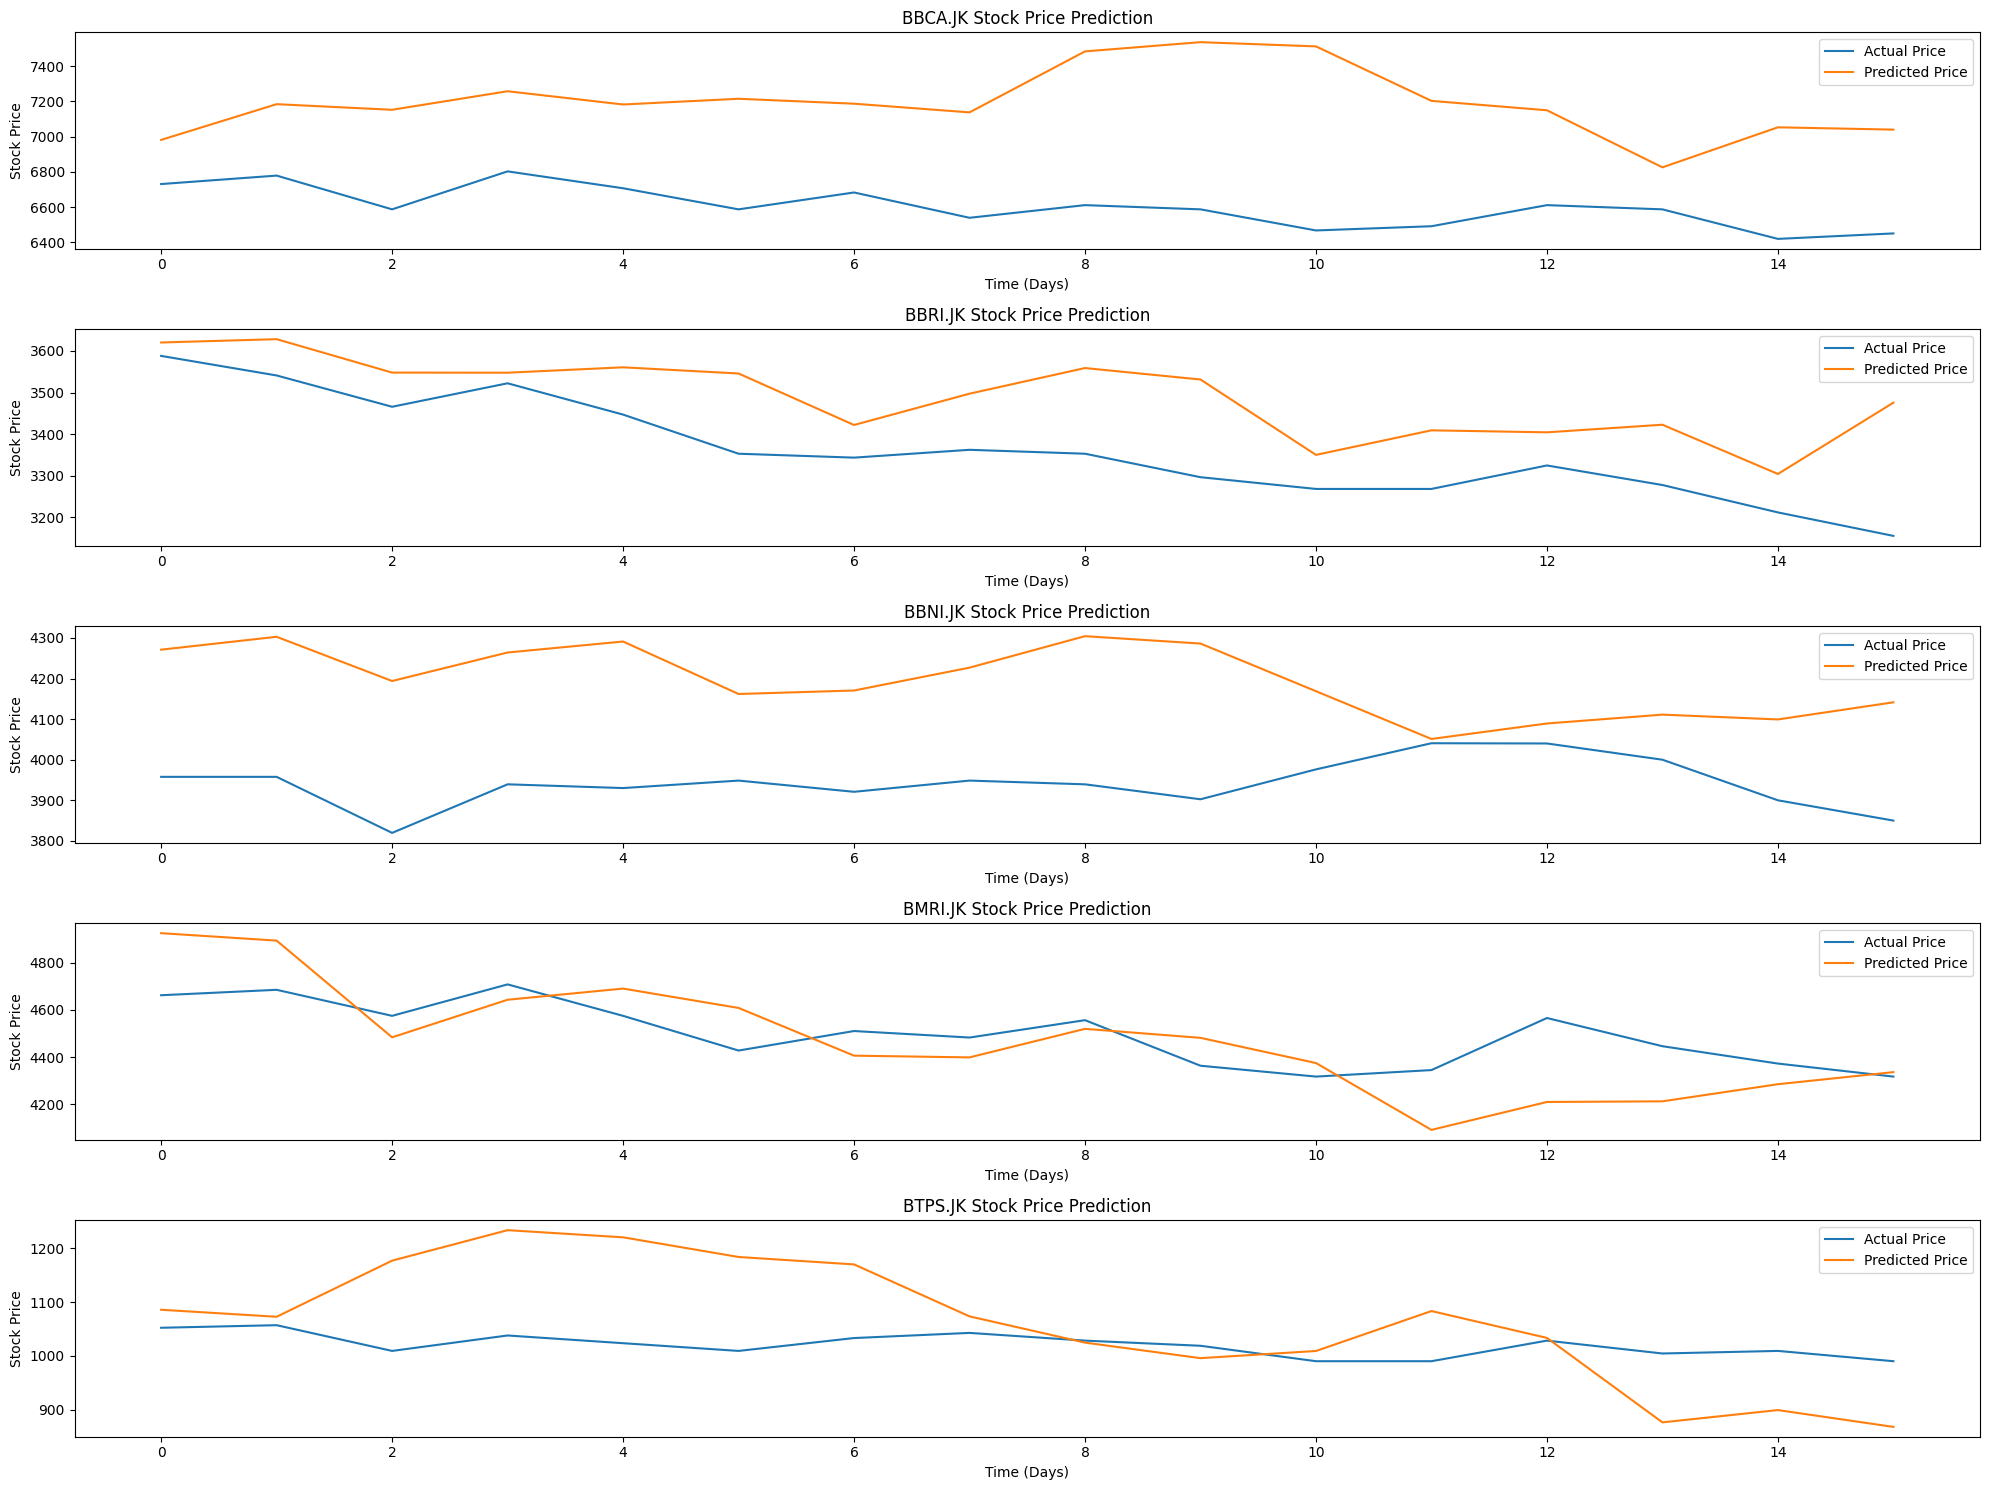

In [21]:
# Plotting the results for each stock
plt.figure(figsize=(20, 15))

for i, ticker in enumerate(indonesian_bank_tickers):
    plt.subplot(len(indonesian_bank_tickers), 1, i + 1)
    plt.plot(actual_prices[ticker], label='Actual Price')
    plt.plot(predicted_prices[ticker], label='Predicted Price')
    plt.title(f'{ticker} Stock Price Prediction')
    plt.xlabel('Time (Days)')
    plt.ylabel('Stock Price')
    plt.legend()

plt.tight_layout()
plt.show()

### Model Valuation

To quantitatively assess the model's performance, we will calculate common regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) for each stock.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\nModel Evaluation Metrics:")
for ticker in indonesian_bank_tickers:
    actual = actual_prices[ticker]
    predicted = predicted_prices[ticker]

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    print(f"\nStock: {ticker}")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")


Model Evaluation Metrics:

Stock: BBCA.JK
  Mean Absolute Error (MAE): 591.25
  Mean Squared Error (MSE): 396375.85
  Root Mean Squared Error (RMSE): 629.58
  R-squared (R2): -31.14

Stock: BBRI.JK
  Mean Absolute Error (MAE): 127.80
  Mean Squared Error (MSE): 22004.54
  Root Mean Squared Error (RMSE): 148.34
  R-squared (R2): -0.58

Stock: BBNI.JK
  Mean Absolute Error (MAE): 253.92
  Mean Squared Error (MSE): 77221.57
  Root Mean Squared Error (RMSE): 277.89
  R-squared (R2): -22.86

Stock: BMRI.JK
  Mean Absolute Error (MAE): 142.00
  Mean Squared Error (MSE): 28774.84
  Root Mean Squared Error (RMSE): 169.63
  R-squared (R2): -0.80

Stock: BTPS.JK
  Mean Absolute Error (MAE): 91.01
  Mean Squared Error (MSE): 13116.26
  Root Mean Squared Error (RMSE): 114.53
  R-squared (R2): -29.63
